# Import Libraries

In [30]:
# General
import os
import random
import numpy as np
import matplotlib.pyplot as plt

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

# Metrics and Evaluation
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve,
    f1_score
)

# Visualisation
import seaborn as sns

# Ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# Set Random Seed

In [31]:
SEED = 42

# Python random seed
random.seed(SEED)

# NumPy random seed
np.random.seed(SEED)

# TensorFlow random seed
tf.random.set_seed(SEED)

print(f"Random seed set to {SEED}")

Random seed set to 42


# Define constants

In [32]:
# Image settings
IMAGE_SIZE = (224, 224)

# Training settings
BATCH_SIZE = 32
EPOCHS = 20
SEED = 42

# Validation split
VALIDATION_SPLIT = 0.2

# TensorFlow performance
AUTOTUNE = tf.data.AUTOTUNE

# Class names
CLASS_NAMES = ["Normal", "TB"]

print("Project constants defined successfully.")

Project constants defined successfully.


# Define Dataset Paths

In [33]:
from pathlib import Path
import os

# Dataset root directory
DATASET_DIR = Path(
    r"C:\Users\PROGRESSIVE\OneDrive\Documents\Data Professional\projects\TB-detection-automation\Nigeria TB dataset"
)

# Dataset subdirectories
TRAIN_DIR = DATASET_DIR / "train_folder"
TEST_DIR = DATASET_DIR / "test_folder"

# Checkpoint directory (inside your project)
CHECKPOINT_DIR = Path(
    r"C:\Users\PROGRESSIVE\OneDrive\Documents\Data Professional\projects\TB-detection-automation\checkpoints"
)

# Create checkpoint directory if it doesn't exist
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

# Verify paths
print("Training Directory  :", TRAIN_DIR)
print("Testing Directory   :", TEST_DIR)
print("Checkpoint Directory:", CHECKPOINT_DIR)

print("\nChecking directories...")

print(f"Train directory exists: {TRAIN_DIR.exists()}")
print(f"Test directory exists : {TEST_DIR.exists()}")
print(f"Checkpoint exists     : {CHECKPOINT_DIR.exists()}")

Training Directory  : C:\Users\PROGRESSIVE\OneDrive\Documents\Data Professional\projects\TB-detection-automation\Nigeria TB dataset\train_folder
Testing Directory   : C:\Users\PROGRESSIVE\OneDrive\Documents\Data Professional\projects\TB-detection-automation\Nigeria TB dataset\test_folder
Checkpoint Directory: C:\Users\PROGRESSIVE\OneDrive\Documents\Data Professional\projects\TB-detection-automation\checkpoints

Checking directories...
Train directory exists: True
Test directory exists : True
Checkpoint exists     : True


# Load the Datasets

In [34]:
# Training Dataset
train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="binary",
    validation_split=VALIDATION_SPLIT,
    subset="training",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

# Validation Dataset
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="binary",
    validation_split=VALIDATION_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

# Test Dataset
test_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="binary",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Save class names before preprocessing
CLASS_NAMES = train_dataset.class_names


# VERIFY DATASETS
print("\nDataset Summary")
print("-" * 40)

print(f"Classes              : {CLASS_NAMES}")
print(f"Training Batches     : {len(train_dataset)}")
print(f"Validation Batches   : {len(validation_dataset)}")
print(f"Testing Batches      : {len(test_dataset)}")

Found 1000 files belonging to 2 classes.
Using 800 files for training.
Found 1000 files belonging to 2 classes.
Using 200 files for validation.
Found 300 files belonging to 2 classes.

Dataset Summary
----------------------------------------
Classes              : ['NORMAL', 'TB']
Training Batches     : 25
Validation Batches   : 7
Testing Batches      : 10


# Dataset Pipeline

In [35]:
# Cache, shuffle and prefetch the training dataset
train_dataset = (
    train_dataset
    .cache()
    .shuffle(1000, seed=SEED)
    .prefetch(buffer_size=AUTOTUNE)
)

# Cache and prefetch the validation dataset
validation_dataset = (
    validation_dataset
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
)

# Cache and prefetch the test dataset
test_dataset = (
    test_dataset
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
)

print("Dataset pipeline created successfully.")

Dataset pipeline created successfully.


# Define Callbacks

In [36]:
# Early Stopping
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Reduce Learning Rate
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

# Callback list
callbacks = [
    early_stopping,
    reduce_lr
]

print("Callbacks defined successfully.")

Callbacks defined successfully.


# Function Definitions

In [37]:
# DISPLAY SAMPLE IMAGES
def plot_sample_images(dataset, class_names, num_images=9):
    """
    Display sample images from a dataset.
    """

    plt.figure(figsize=(10, 10))

    for images, labels in dataset.take(1):
        for i in range(num_images):
            ax = plt.subplot(3, 3, i + 1)

            plt.imshow(images[i].numpy().astype("uint8"))

            label = int(labels[i])
            plt.title(class_names[label])

            plt.axis("off")

    plt.tight_layout()
    plt.show()

In [38]:
# PLOT TRAINING HISTORY
def plot_training_history(history):
    """
    Plot training history with the best validation loss epoch highlighted.
    """

    # Best epoch (lowest validation loss)
    best_epoch = np.argmin(history.history["val_loss"]) + 1

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))


    # Accuracy
    axes[0].plot(history.history["accuracy"], label="Training Accuracy")
    axes[0].plot(history.history["val_accuracy"], label="Validation Accuracy")

    axes[0].axvline(
        best_epoch - 1,
        color="red",
        linestyle="--",
        label=f"Best Epoch ({best_epoch})"
    )

    axes[0].set_title("Training and Validation Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()


    # Loss
    axes[1].plot(history.history["loss"], label="Training Loss")
    axes[1].plot(history.history["val_loss"], label="Validation Loss")

    axes[1].axvline(
        best_epoch - 1,
        color="red",
        linestyle="--",
        label=f"Best Epoch ({best_epoch})"
    )

    axes[1].set_title("Training and Validation Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

In [39]:
# TRAIN MODEL
def train_model(model,
                train_dataset,
                validation_dataset,
                callbacks,
                epochs=EPOCHS):

    """
    Train a deep learning model.
    """

    history = model.fit(
        train_dataset,
        validation_data=validation_dataset,
        epochs=epochs,
        callbacks=callbacks,
        verbose=1
    )

    return history

In [40]:
# EVALUATE MODEL
def evaluate_model(model, test_dataset):
    """
    Evaluate a trained model on the test dataset.
    Returns evaluation metrics and data for visualisation.
    """

    # Predict probabilities
    y_prob = model.predict(test_dataset, verbose=0).ravel()

    # Convert probabilities to class predictions
    y_pred = (y_prob >= 0.5).astype(int)

    # True labels
    y_true = np.concatenate(
        [labels.numpy().astype(int).ravel() for _, labels in test_dataset]
    )

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    # Metrics
    accuracy = (tp + tn) / (tp + tn + fp + fn)

    sensitivity = tp / (tp + fn)

    specificity = tn / (tn + fp)

    f1 = f1_score(y_true, y_pred)

    # ROC Curve and AUC
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    # Store results
    results = {
        "accuracy": accuracy,
        "f1_score": f1,
        "sensitivity": sensitivity,
        "specificity": specificity,
        "roc_auc": roc_auc,
        "confusion_matrix": cm,
        "fpr": fpr,
        "tpr": tpr
    }

    return results

In [41]:
# PLOT CONFUSION MATRIX
def plot_confusion_matrix(confusion_matrix, class_names):
    """
    Plot the confusion matrix.
    """

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        confusion_matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.title("Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    plt.show()

In [42]:
# PLOT ROC CURVE
def plot_roc_curve(fpr, tpr, roc_auc):
    """
    Plot the ROC curve.
    """

    plt.figure(figsize=(6, 5))

    plt.plot(
        fpr,
        tpr,
        label=f"AUC = {roc_auc:.4f}",
        linewidth=2
    )

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--"
    )

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("AUC-ROC Curve")
    plt.legend(loc="lower right")

    plt.show()

In [43]:
# PREDICT SINGLE IMAGE
def predict_image(model, image_path, image_size=IMAGE_SIZE):
    """
    Predict whether a single chest X-ray is TB or Normal.
    """

    image = tf.keras.utils.load_img(
        image_path,
        target_size=image_size
    )

    image = tf.keras.utils.img_to_array(image)
    image = np.expand_dims(image, axis=0)

    probability = model.predict(image, verbose=0)[0][0]

    prediction = "TB" if probability >= 0.5 else "Normal"

    print(f"Prediction : {prediction}")
    print(f"Probability: {probability:.4f}")

    return prediction, probability

In [44]:
# BUILD BASELINE CNN
def build_baseline_cnn():

    model = tf.keras.Sequential([

        layers.Input(shape=(*IMAGE_SIZE, 3)),

        layers.Rescaling(1./255),

        layers.Conv2D(32, (3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),

        layers.Conv2D(64, (3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),

        layers.Conv2D(128, (3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),

        layers.Flatten(),

        layers.Dense(128, activation="relu"),

        layers.Dense(1, activation="sigmoid")

    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.AUC(name="auc")
        ]
    )

    return model

# Baseline CNN

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_4 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step - accuracy: 0.7563 - auc: 0.8429 - loss: 0.4727 - precision: 0.7725 - recall: 0.7282
Epoch 1: val_loss improved from None to 0.45593, saving model to C:\Users\PROGRESSIVE\OneDrive\Documents\Data Professional\projects\TB-detection-automation\checkpoints\baseline_cnn.keras

Epoch 1: finished saving model to C:\Users\PROGRESSIVE\OneDrive\Documents\Data Professional\projects\TB-detection-automation\checkpoints\baseline_cnn.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 16s 529ms/step - accuracy: 0.7563 - auc: 0.8429 - loss: 0.4727 - precision: 0.7725 - recall: 0.7282 - val_accuracy: 0.8200 - val_auc: 0.9510 - val_loss: 0.4559 - val_precision: 0.7480 - val_recall: 0.9596 - learning_rate: 0.0010
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step - accuracy: 0.9150 - auc: 0.9692 - loss: 0.2251 - precision: 0.9194 - recall: 0.9102
Epoch 2: val_loss improved from 0.45593 to 0.21552, saving model to C:\Users\PROGRESSIVE\OneDrive\Documents\Data Professional\

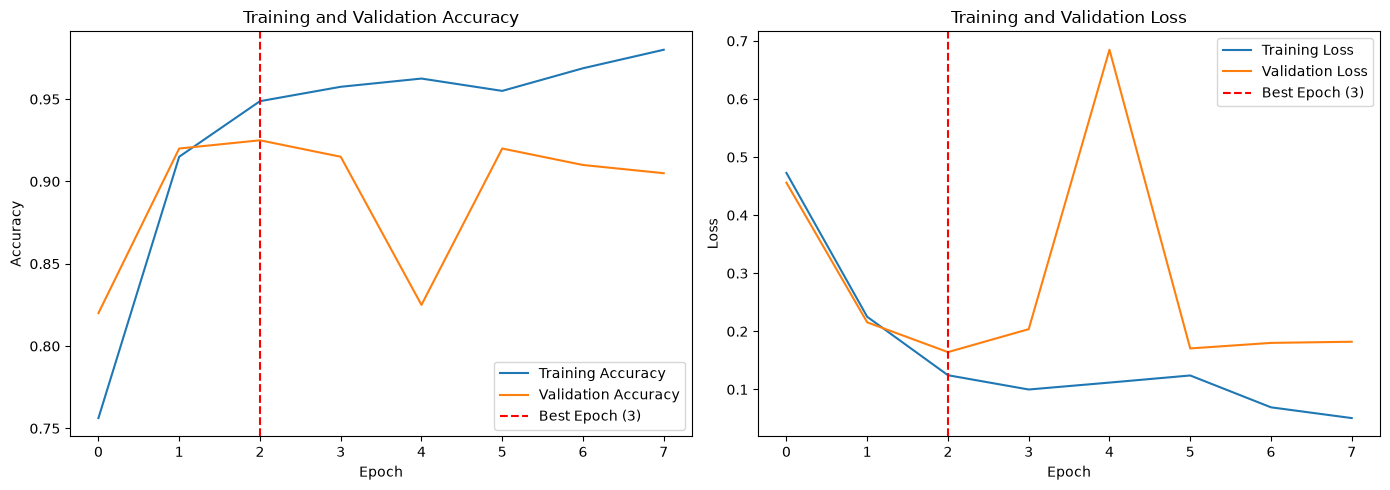

In [45]:
# BUILD MODEL
baseline_cnn = build_baseline_cnn()

baseline_cnn.summary()


# MODEL CHECKPOINT
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=os.path.join(CHECKPOINT_DIR, "baseline_cnn.keras"),
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

model_callbacks = callbacks + [checkpoint]


# TRAIN MODEL
history = train_model(
    model=baseline_cnn,
    train_dataset=train_dataset,
    validation_dataset=validation_dataset,
    callbacks=model_callbacks
)


# TRAINING HISTORY
plot_training_history(history)

Accuracy    : 0.9233
F1-score    : 0.9204
Sensitivity : 0.8867
Specificity : 0.9600
ROC-AUC     : 0.9760


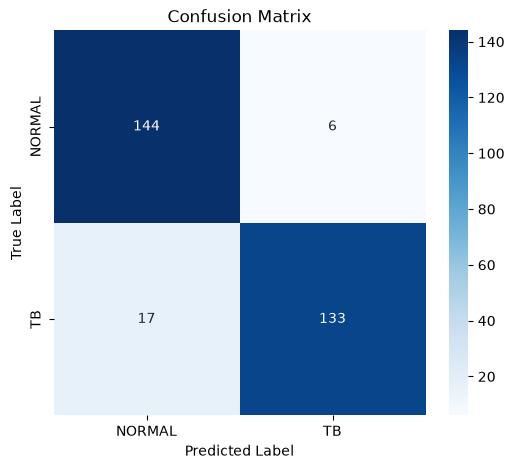

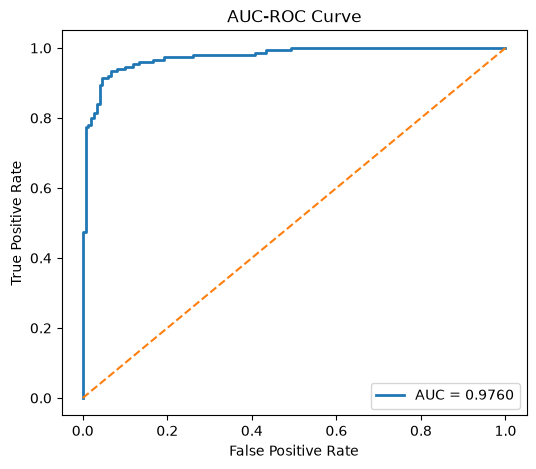

In [46]:
# MODEL EVALUATION
results = evaluate_model(
    baseline_cnn,
    test_dataset
)

print(f"Accuracy    : {results['accuracy']:.4f}")
print(f"F1-score    : {results['f1_score']:.4f}")
print(f"Sensitivity : {results['sensitivity']:.4f}")
print(f"Specificity : {results['specificity']:.4f}")
print(f"ROC-AUC     : {results['roc_auc']:.4f}")


# CONFUSION MATRIX
plot_confusion_matrix(
    results["confusion_matrix"],
    CLASS_NAMES
)


# ROC CURVE
plot_roc_curve(
    results["fpr"],
    results["tpr"],
    results["roc_auc"]
)

# Custom CNN Optimisation

### Optimisation Components

In [47]:
# Online Data Augmentation
data_augmentation = tf.keras.Sequential(
    [
        layers.RandomRotation(0.05),
        layers.RandomZoom(0.10),
        layers.RandomTranslation(
            height_factor=0.05,
            width_factor=0.05
        ),
        layers.RandomContrast(0.10)
    ],
    name="data_augmentation"
)


# L2 Regularisation
L2_REG = regularizers.l2(0.001)


# Dropout Rates
CONV_DROPOUT = 0.20
DENSE_DROPOUT = 0.50

print("Optimisation components initialised successfully.")

Optimisation components initialised successfully.


### Build, Compile and Train the Optimised CNN

In [48]:
# Build Optimised CNN
def build_optimized_cnn():

    model = tf.keras.Sequential([

        # Input
        layers.Input(shape=(*IMAGE_SIZE, 3)),

        # Data Augmentation
        data_augmentation,

        # Rescale pixel values
        layers.Rescaling(1./255),

        
        # Convolution Block 1
        layers.Conv2D(
            32,
            (3, 3),
            activation="relu",
            kernel_regularizer=L2_REG
        ),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Dropout(CONV_DROPOUT),

       
        # Convolution Block 2
        layers.Conv2D(
            64,
            (3, 3),
            activation="relu",
            kernel_regularizer=L2_REG
        ),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Dropout(CONV_DROPOUT),

        
        # Convolution Block 3
        layers.Conv2D(
            128,
            (3, 3),
            activation="relu",
            kernel_regularizer=L2_REG
        ),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Dropout(CONV_DROPOUT),

        # Classification Head
        layers.Flatten(),

        layers.Dense(
            128,
            activation="relu",
            kernel_regularizer=L2_REG
        ),

        layers.Dropout(DENSE_DROPOUT),

        layers.Dense(1, activation="sigmoid")

    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.AUC(name="auc")
        ]
    )

    return model

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_5 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 18s 612ms/step - accuracy: 0.5763 - auc: 0.6034 - loss: 1.3228 - precision: 0.5633 - recall: 0.6883 - val_accuracy: 0.6400 - val_auc: 0.9616 - val_loss: 0.9162 - val_precision: 1.0000 - val_recall: 0.2727 - learning_rate: 0.0010
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 14s 578ms/step - accuracy: 0.7812 - auc: 0.8650 - loss: 0.7711 - precision: 0.7989 - recall: 0.7531 - val_accuracy: 0.8900 - val_auc: 0.9463 - val_loss: 0.6182 - val_precision: 0.8812 - val_recall: 0.8990 - learning_rate: 0.0010
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 20s 549ms/step - accuracy: 0.8587 - auc: 0.9251 - loss: 0.5983 - precision: 0.8711 - recall: 0.8429 - val_accuracy: 0.8800 - val_auc: 0.9484 - val_loss: 0.5228 - val_precision: 0.8505 - val_recall: 0.9192 - learning_rate: 0.0010
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 15s 593ms/step - accuracy: 0.8838 - auc: 0.9447 - loss: 0.5114 - precision: 0.8929 - recall: 0.8728 - val_accuracy: 0.8400 - val_auc: 0.9667 - val_loss: 0.5111 -

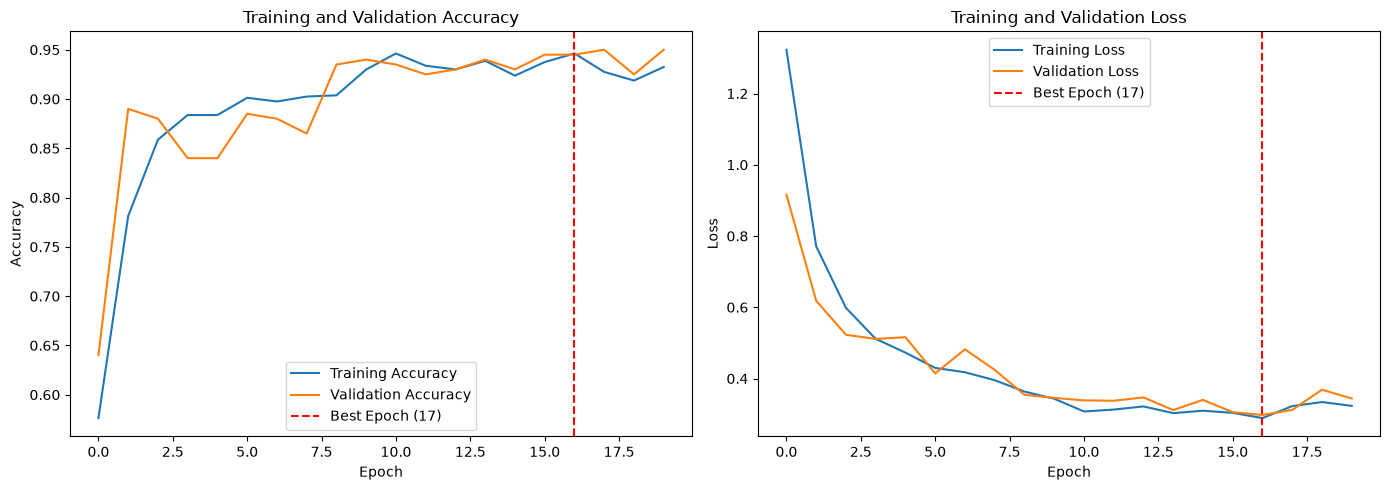

In [49]:
# Build model
optimized_cnn = build_optimized_cnn()

# Display model summary
optimized_cnn.summary()

# Train model
history = train_model(
    model=optimized_cnn,
    train_dataset=train_dataset,
    validation_dataset=validation_dataset,
    callbacks=callbacks
)

# TRAINING HISTORY
plot_training_history(history)

Accuracy    : 0.9433
F1-score    : 0.9424
Sensitivity : 0.9267
Specificity : 0.9600
ROC-AUC     : 0.9785


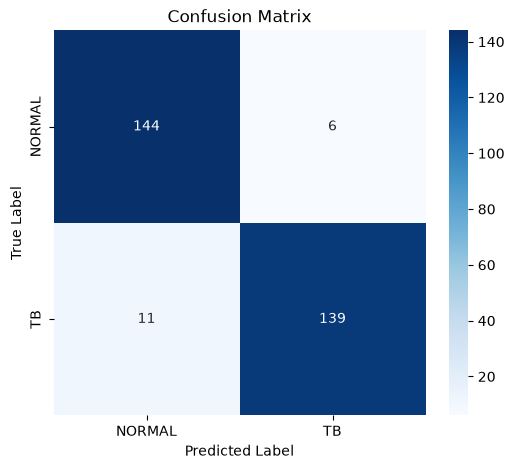

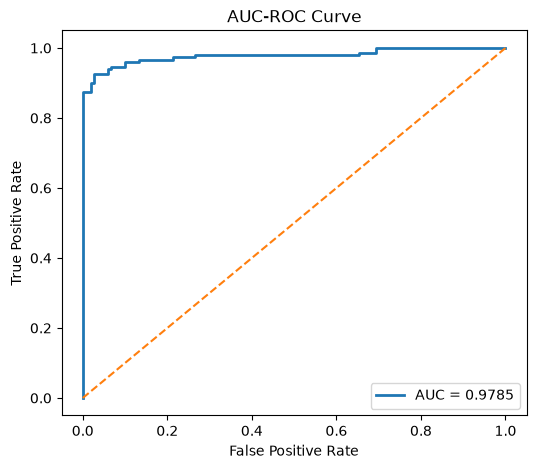

In [51]:
# MODEL EVALUATION
results = evaluate_model(
    optimized_cnn,
    test_dataset
)

print(f"Accuracy    : {results['accuracy']:.4f}")
print(f"F1-score    : {results['f1_score']:.4f}")
print(f"Sensitivity : {results['sensitivity']:.4f}")
print(f"Specificity : {results['specificity']:.4f}")
print(f"ROC-AUC     : {results['roc_auc']:.4f}")


# CONFUSION MATRIX
plot_confusion_matrix(
    results["confusion_matrix"],
    CLASS_NAMES
)


# ROC CURVE
plot_roc_curve(
    results["fpr"],
    results["tpr"],
    results["roc_auc"]
)

# ResNet50

### Build, Compile and Train

In [53]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras import layers, models

# Load pretrained ResNet50
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(*IMAGE_SIZE, 3)
)

# Freeze pretrained layers
base_model.trainable = False

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 38s 0us/step


In [54]:
def build_resnet50():

    inputs = layers.Input(shape=(*IMAGE_SIZE, 3))

    # Data augmentation
    x = data_augmentation(inputs)

    # ResNet50 preprocessing
    x = preprocess_input(x)

    # Feature extraction
    x = base_model(x, training=False)

    # Classification head
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(
        128,
        activation="relu",
        kernel_regularizer=L2_REG
    )(x)

    x = layers.Dropout(DENSE_DROPOUT)(x)

    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = models.Model(inputs, outputs)

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.AUC(name="auc")
        ]
    )

    return model

Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_13      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 224, 224,  │          0 │ input_layer_13[0… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_12         │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_13         │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_14         │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_4 (Stack)     │ (None, 224, 224,  │          0 │ get_item_12[0][0… │
│                     │ 3)                │            │ get_item_13[0][0… │
│                     │                   │            │ get_item_14[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 224, 224,  │          0 │ stack_4[0][0]     │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add_4[0][0]       │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[4][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_20 (Dense)    │ (None, 128)       │    262,272 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_20          │ (None, 128)       │          0 │ dense_20[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_21 (Dense)    │ (None, 1)         │        129 │ dropout_20[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 55s 2s/step - accuracy: 0.8475 - auc: 0.9248 - loss: 0.5828 - precision: 0.8496 - recall: 0.8454 - val_accuracy: 0.9250 - val_auc: 0.9756 - val_loss: 0.3976 - val_precision: 0.9565 - val_recall: 0.8889 - learning_rate: 0.0010
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - accuracy: 0.9513 - auc: 0.9914 - loss: 0.3126 - precision: 0.9548 - recall: 0.9476 - val_accuracy: 0.9250 - val_auc: 0.9809 - val_loss: 0.3495 - val_precision: 0.9565 - val_recall: 0.8889 - learning_rate: 0.0010
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 56s 2s/step - accuracy: 0.9538 - auc: 0.9898 - loss: 0.2919 - precision: 0.9550 - recall: 0.9526 - val_accuracy: 0.9400 - val_auc: 0.9868 - val_loss: 0.3019 - val_precision: 0.9485 - val_recall: 0.9293 - learning_rate: 0.0010
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 55s 2s/step - accuracy: 0.9563 - auc: 0.9912 - loss: 0.2676 - precision: 0.9575 - recall: 0.9551 - val_accuracy: 0.9450 - val_auc: 0.9909 - val_loss: 0.2696 - val_precisi

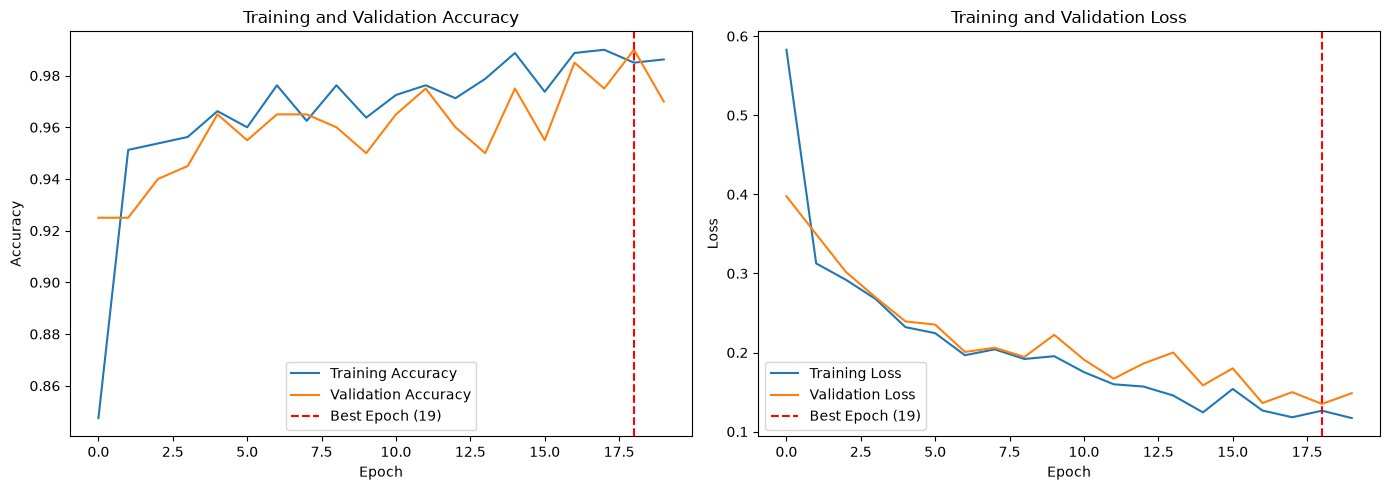

In [60]:
# Build model
resnet50 = build_resnet50()

# Display model summary
resnet50.summary()

# Train model
history = train_model(
    model=resnet50,
    train_dataset=train_dataset,
    validation_dataset=validation_dataset,
    callbacks=callbacks
)

# TRAINING HISTORY
plot_training_history(history)

Accuracy    : 0.9767
F1-score    : 0.9763
Sensitivity : 0.9600
Specificity : 0.9933
ROC-AUC     : 0.9984


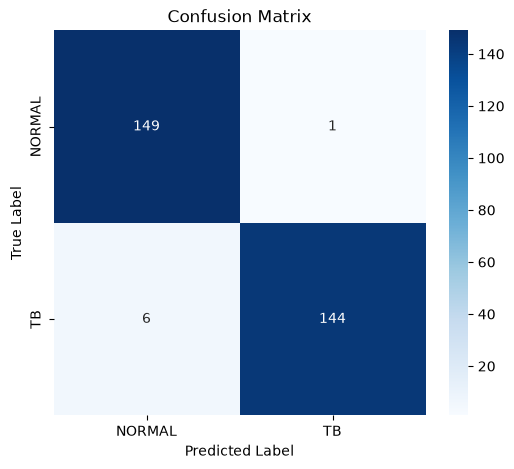

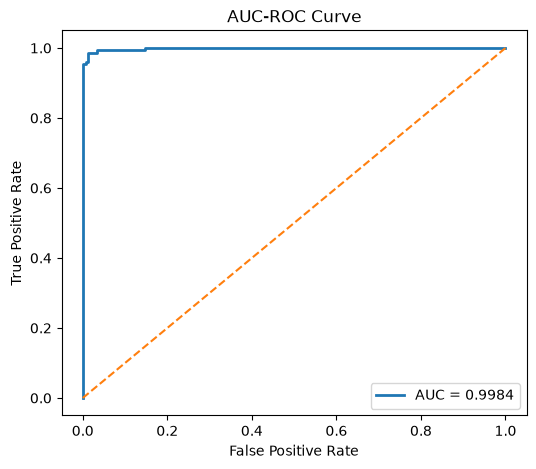

In [61]:
# MODEL EVALUATION
results = evaluate_model(
    resnet50,
    test_dataset
)

print(f"Accuracy    : {results['accuracy']:.4f}")
print(f"F1-score    : {results['f1_score']:.4f}")
print(f"Sensitivity : {results['sensitivity']:.4f}")
print(f"Specificity : {results['specificity']:.4f}")
print(f"ROC-AUC     : {results['roc_auc']:.4f}")


# CONFUSION MATRIX
plot_confusion_matrix(
    results["confusion_matrix"],
    CLASS_NAMES
)


# ROC CURVE
plot_roc_curve(
    results["fpr"],
    results["tpr"],
    results["roc_auc"]
)

# DenseNet121

In [62]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input
from tensorflow.keras import layers, models

# Load pretrained DenseNet121
base_model = DenseNet121(
    weights="imagenet",
    include_top=False,
    input_shape=(*IMAGE_SIZE, 3)
)

# Freeze pretrained layers
base_model.trainable = False

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 12s 0us/step


In [63]:
def build_densenet121():

    inputs = layers.Input(shape=(*IMAGE_SIZE, 3))

    # Data augmentation
    x = data_augmentation(inputs)

    # DenseNet preprocessing
    x = preprocess_input(x)

    # Feature extraction
    x = base_model(x, training=False)

    # Classification Head
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(
        128,
        activation="relu",
        kernel_regularizer=L2_REG
    )(x)

    x = layers.Dropout(DENSE_DROPOUT)(x)

    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = models.Model(inputs, outputs)

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.AUC(name="auc")
        ]
    )

    return model


In [64]:
# Build model
densenet121 = build_densenet121()

# Display model summary
densenet121.summary()

# Train model
history = train_model(
    model=densenet121,
    train_dataset=train_dataset,
    validation_dataset=validation_dataset,
    callbacks=callbacks
)

Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_15 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add_5 (Add)                     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,168,833 (27.35 MB)

 Trainable params: 131,329 (513.00 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 57s 2s/step - accuracy: 0.7337 - auc: 0.8233 - loss: 0.7032 - precision: 0.7386 - recall: 0.7257 - val_accuracy: 0.7800 - val_auc: 0.9466 - val_loss: 0.5705 - val_precision: 0.9825 - val_recall: 0.5657 - learning_rate: 0.0010
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.8963 - auc: 0.9604 - loss: 0.3946 - precision: 0.9119 - recall: 0.8778 - val_accuracy: 0.9100 - val_auc: 0.9591 - val_loss: 0.3846 - val_precision: 0.9551 - val_recall: 0.8586 - learning_rate: 0.0010
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.9038 - auc: 0.9721 - loss: 0.3295 - precision: 0.9091 - recall: 0.8978 - val_accuracy: 0.9000 - val_auc: 0.9688 - val_loss: 0.3582 - val_precision: 0.9877 - val_recall: 0.8081 - learning_rate: 0.0010
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 73s 2s/step - accuracy: 0.9388 - auc: 0.9830 - loss: 0.2707 - precision: 0.9583 - recall: 0.9177 - val_accuracy: 0.9150 - val_auc: 0.9723 - val_loss: 0.3156 - val_precisi

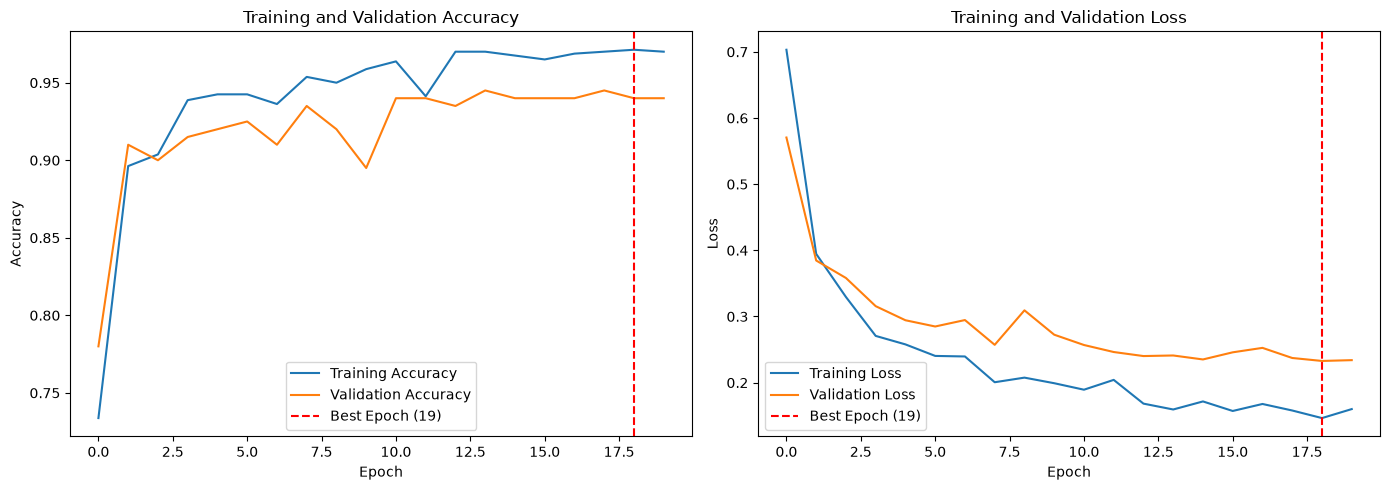

In [65]:
# TRAINING HISTORY
plot_training_history(history)

Accuracy    : 0.9500
F1-score    : 0.9485
Sensitivity : 0.9200
Specificity : 0.9800
ROC-AUC     : 0.9905


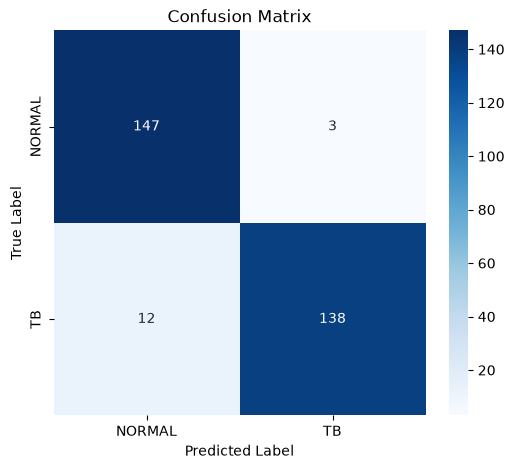

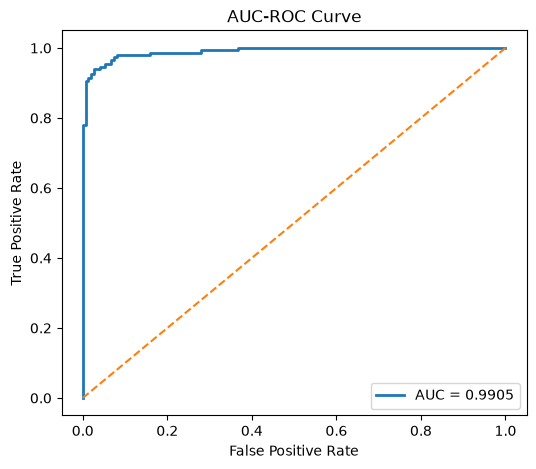

In [66]:
# MODEL EVALUATION
results = evaluate_model(
    densenet121,
    test_dataset
)

print(f"Accuracy    : {results['accuracy']:.4f}")
print(f"F1-score    : {results['f1_score']:.4f}")
print(f"Sensitivity : {results['sensitivity']:.4f}")
print(f"Specificity : {results['specificity']:.4f}")
print(f"ROC-AUC     : {results['roc_auc']:.4f}")


# CONFUSION MATRIX
plot_confusion_matrix(
    results["confusion_matrix"],
    CLASS_NAMES
)


# ROC CURVE
plot_roc_curve(
    results["fpr"],
    results["tpr"],
    results["roc_auc"]
)

# MobileNetV2

In [67]:
# Build, Compile and Train MobileNetV2
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras import layers, models

# Load pretrained MobileNetV2
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(*IMAGE_SIZE, 3)
)

# Freeze pretrained layers
base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [68]:
def build_mobilenetv2():

    inputs = layers.Input(shape=(*IMAGE_SIZE, 3))

    # Data augmentation
    x = data_augmentation(inputs)

    # MobileNetV2 preprocessing
    x = preprocess_input(x)

    # Feature extraction
    x = base_model(x, training=False)

    # Classification Head
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(
        128,
        activation="relu",
        kernel_regularizer=L2_REG
    )(x)

    x = layers.Dropout(DENSE_DROPOUT)(x)

    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = models.Model(inputs, outputs)

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.AUC(name="auc")
        ]
    )

    return model

Model: "functional_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_17 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_2 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 20s 548ms/step - accuracy: 0.7663 - auc: 0.8548 - loss: 0.6894 - precision: 0.7702 - recall: 0.7606 - val_accuracy: 0.9050 - val_auc: 0.9791 - val_loss: 0.4450 - val_precision: 0.9878 - val_recall: 0.8182 - learning_rate: 0.0010
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 403ms/step - accuracy: 0.9075 - auc: 0.9710 - loss: 0.4004 - precision: 0.9182 - recall: 0.8953 - val_accuracy: 0.8300 - val_auc: 0.9871 - val_loss: 0.5573 - val_precision: 1.0000 - val_recall: 0.6566 - learning_rate: 0.0010
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 412ms/step - accuracy: 0.9337 - auc: 0.9853 - loss: 0.3231 - precision: 0.9416 - recall: 0.9252 - val_accuracy: 0.8850 - val_auc: 0.9880 - val_loss: 0.4338 - val_precision: 1.0000 - val_recall: 0.7677 - learning_rate: 0.0010
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 450ms/step - accuracy: 0.9425 - auc: 0.9855 - loss: 0.3022 - precision: 0.9471 - recall: 0.9377 - val_accuracy: 0.8950 - val_auc: 0.9889 - val_loss: 0.3968 -

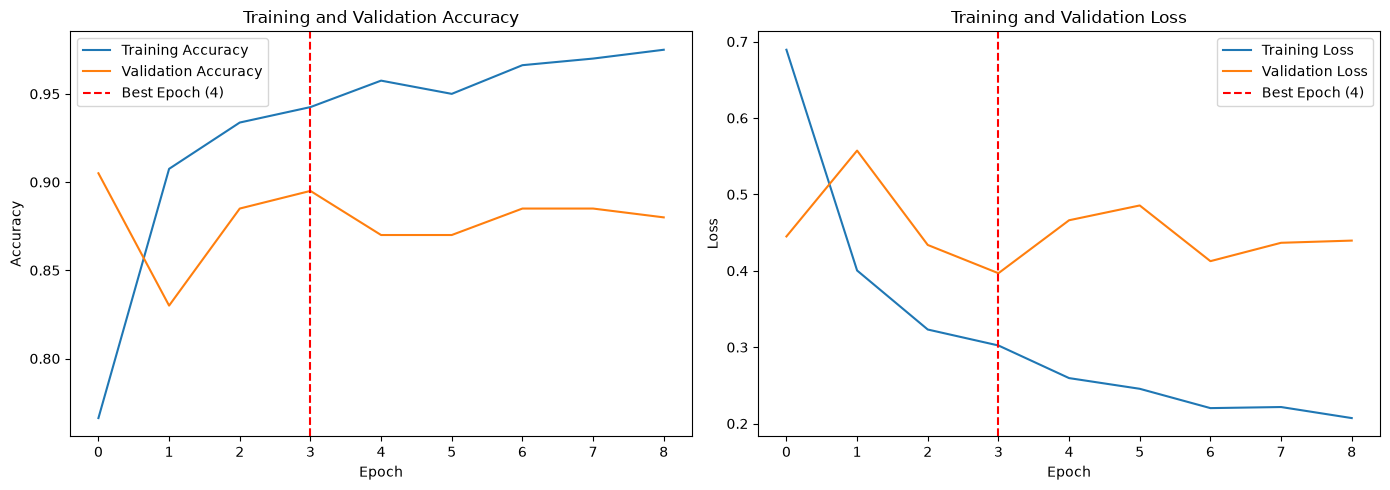

In [69]:
# Build model
mobilenetv2 = build_mobilenetv2()

# Display model summary
mobilenetv2.summary()

# Train model
history = train_model(
    model=mobilenetv2,
    train_dataset=train_dataset,
    validation_dataset=validation_dataset,
    callbacks=callbacks
)

# TRAINING HISTORY
plot_training_history(history)

Accuracy    : 0.8500
F1-score    : 0.8235
Sensitivity : 0.7000
Specificity : 1.0000
ROC-AUC     : 0.9909


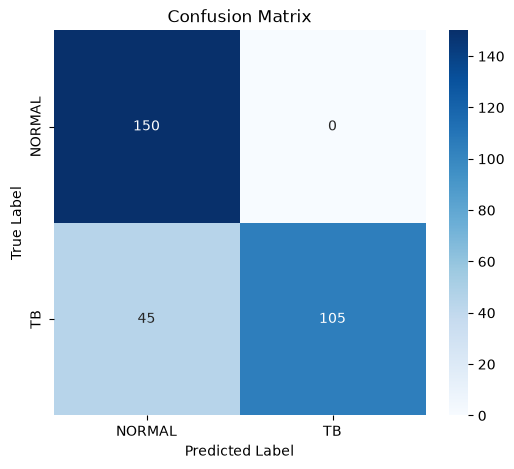

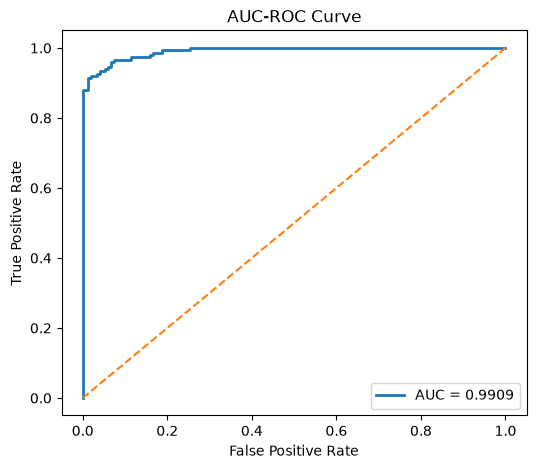

In [70]:
# MODEL EVALUATION
results = evaluate_model(
    mobilenetv2,
    test_dataset
)

print(f"Accuracy    : {results['accuracy']:.4f}")
print(f"F1-score    : {results['f1_score']:.4f}")
print(f"Sensitivity : {results['sensitivity']:.4f}")
print(f"Specificity : {results['specificity']:.4f}")
print(f"ROC-AUC     : {results['roc_auc']:.4f}")


# CONFUSION MATRIX
plot_confusion_matrix(
    results["confusion_matrix"],
    CLASS_NAMES
)


# ROC CURVE
plot_roc_curve(
    results["fpr"],
    results["tpr"],
    results["roc_auc"]
)